In [2]:
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


# MSG as State

In [1]:
from typing import TypedDict, Annotated
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

# Simplifies message as state

In [2]:
from langgraph.graph import MessagesState

class State(MessagesState):
    # Add any keys needed beyond messages, which is pre-built 
    pass

In [3]:
import os
from dotenv import load_dotenv
load_dotenv('../../../azure.env')
os.environ["AZURE_OPENAI_API_VERSION"] = "2024-06-01"
os.environ["AZURE_OPENAI_DEPLOYMENT_NAME"] = 'gpt-4o-mini'

In [4]:
from langchain_openai import AzureChatOpenAI

model = AzureChatOpenAI(
    azure_endpoint=os.environ["AZURE_OPENAI_ENDPOINT"],
    azure_deployment=os.environ["AZURE_OPENAI_DEPLOYMENT_NAME"],
    openai_api_version=os.environ["AZURE_OPENAI_API_VERSION"],
)

# LLM with Tool

In [5]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

llm_with_tools = model.bind_tools([multiply])

# Graph

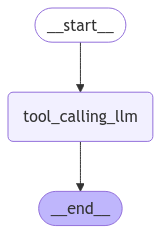

In [6]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
    
# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_edge(START, "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
messages = graph.invoke({"messages": HumanMessage(content="Hello!")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello!
================================== Ai Message ==================================

Hello! How can I assist you today?


In [8]:
messages = graph.invoke({"messages": HumanMessage(content="Multiply 5 and 6")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiply 5 and 6
================================== Ai Message ==================================
Tool Calls:
  multiply (call_KFmIAFv6BJDTnbXgcHQC7X3K)
 Call ID: call_KFmIAFv6BJDTnbXgcHQC7X3K
  Args:
    a: 5
    b: 6
